In [15]:
import pandas as pd

df = pd.read_csv("apple_quality.csv")
df = df.dropna(subset=["A_id"]).reset_index(drop=True)
df["Acidity"] = pd.to_numeric(df["Acidity"], errors="coerce")

df.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984,good


In [16]:
# Числовые признаки (без идентификатора A_id)
num_cols = ["Size", "Weight", "Sweetness", "Crunchiness",
            "Juiciness", "Ripeness", "Acidity"]

# имя desc (не "stats"), чтобы не затенять модуль scipy.stats, импортируемый ниже
desc = pd.DataFrame({
    "mean":   df[num_cols].mean(),        # среднее
    "median": df[num_cols].median(),      # медиана
    "Q1":     df[num_cols].quantile(0.25),# первый квартиль
    "Q2":     df[num_cols].quantile(0.50),# второй квартиль (= медиана)
    "Q3":     df[num_cols].quantile(0.75),# третий квартиль
    "std":    df[num_cols].std(),         # стандартное отклонение
})

desc

,mean,median,Q1,Q2,Q3,std
Size,-0.503015,-0.513703,-1.816765,-0.513703,0.805526,1.928059
Weight,-0.989547,-0.984736,-2.011770,-0.984736,0.030976,1.602507
Sweetness,-0.470479,-0.504758,-1.738425,-0.504758,0.801922,1.943441
Crunchiness,0.985478,0.998249,0.062764,0.998249,1.894234,1.402757
Juiciness,0.512118,0.534219,-0.801286,0.534219,1.835976,1.930286
Ripeness,0.498277,0.503445,-0.771677,0.503445,1.766212,1.874427
Acidity,0.076877,0.022609,-1.377424,0.022609,1.510493,2.110270


In [17]:
# Где среднее расходится с медианой и какой разброс

skew = pd.DataFrame({
    "mean":        df[num_cols].mean(),
    "median":      df[num_cols].median(),
    "mean-median": df[num_cols].mean() - df[num_cols].median(),  # знак = направление асимметрии
    "std":         df[num_cols].std(),                            # разброс (стандартное отклонение)
    "IQR":         df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25),  # межквартильный разброс
    "skew":        df[num_cols].skew(),                           # коэффициент асимметрии
})

# Насколько среднее смещено относительно медианы в долях разброса (std).
# Это безразмерная мера: |значение| > ~0.1 уже заметная асимметрия.
skew["gap / std"] = skew["mean-median"] / skew["std"]

skew.sort_values("gap / std", key=abs, ascending=False)


,mean,median,mean-median,std,IQR,skew,gap / std
Acidity,0.076877,0.022609,0.054268,2.110270,2.887917,0.055783,0.025716
Sweetness,-0.470479,-0.504758,0.034280,1.943441,2.540347,0.083850,0.017639
Juiciness,0.512118,0.534219,-0.022101,1.930286,2.637262,-0.113421,-0.011449
Crunchiness,0.985478,0.998249,-0.012772,1.402757,1.831470,0.000230,-0.009105
Size,-0.503015,-0.513703,0.010688,1.928059,2.622291,-0.002437,0.005543
Weight,-0.989547,-0.984736,-0.004810,1.602507,2.042747,0.003102,-0.003002
Ripeness,0.498277,0.503445,-0.005167,1.874427,2.537889,-0.008764,-0.002757


### Что показывают расчёты

**Где среднее расходится с медианой.** Сильнее всего (по модулю `gap / std`):
- **Acidity** — gap = +0.054, медиана < среднего → лёгкий правый хвост (есть единичные очень кислые яблоки, которые тянут среднее вверх).
- **Sweetness** — gap = +0.034, тоже слабая правая асимметрия.
- **Juiciness** — gap = −0.022, наоборот, лёгкий левый хвост.

**Разброс.** Признаки уже стандартизованы (std ≈ 1.4–2.1, среднее близко к 0), поэтому величины сопоставимы:
- самый широкий разброс у **Acidity** (std = 2.11, IQR = 2.89);
- самый узкий — у **Crunchiness** (std = 1.40, IQR = 1.83).

**О чём это говорит.** Расхождение среднего и медианы крошечное: `gap / std` нигде не превышает **0.026**, коэффициенты асимметрии (`skew`) близки к нулю (|skew| < 0.12). То есть распределения почти симметричны, выраженных перекосов и доминирующих выбросов нет — данные похожи на заранее нормализованные (z-score). Практический вывод: для этих признаков среднее является надёжной оценкой центра, специальная обработка асимметрии или агрессивная чистка выбросов перед моделированием не требуется.


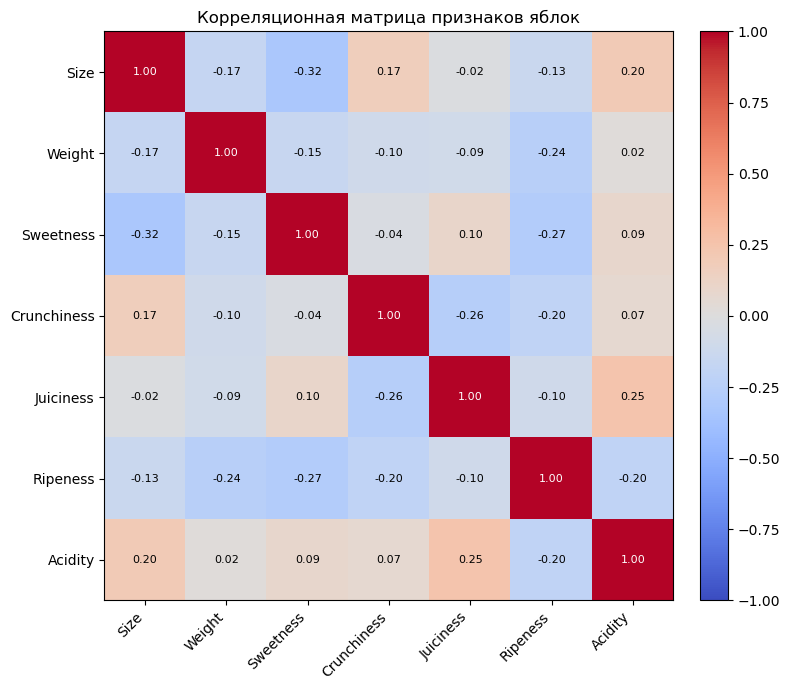

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
Size,1.000,-0.171,-0.325,0.170,-0.019,-0.135,0.196
Weight,-0.171,1.000,-0.154,-0.096,-0.092,-0.244,0.016
Sweetness,-0.325,-0.154,1.000,-0.038,0.096,-0.274,0.086
Crunchiness,0.170,-0.096,-0.038,1.000,-0.260,-0.202,0.070
Juiciness,-0.019,-0.092,0.096,-0.260,1.000,-0.097,0.249
Ripeness,-0.135,-0.244,-0.274,-0.202,-0.097,1.000,-0.203
Acidity,0.196,0.016,0.086,0.070,0.249,-0.203,1.000


In [18]:
# Корреляционная матрица (Пирсон) + тепловая карта (чистый matplotlib)
import matplotlib.pyplot as plt

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right"); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else "black", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Корреляционная матрица признаков яблок")
plt.tight_layout()
plt.show()

corr.round(3)


In [19]:
# Все пары признаков: коэффициент r, p-значение и оценка значимости
from scipy import stats
from itertools import combinations

rows = []
for a, b in combinations(num_cols, 2):
    r, p = stats.pearsonr(df[a], df[b])
    rows.append({"pair": f"{a} – {b}", "r": r, "p_value": p})

pairs = pd.DataFrame(rows)
# Поправка Бонферрони на множественные сравнения (21 пара)
n_tests = len(pairs)
pairs["significant (α=0.05/Bonf)"] = pairs["p_value"] < (0.05 / n_tests)
pairs = pairs.reindex(pairs["r"].abs().sort_values(ascending=False).index)

print(f"Наблюдений n = {len(df)},  число пар (тестов) = {n_tests}\n")
print("Самые сильные ПОЛОЖИТЕЛЬНЫЕ:")
print(pairs[pairs.r > 0].head(3).to_string(index=False), "\n")
print("Самые сильные ОТРИЦАТЕЛЬНЫЕ:")
print(pairs[pairs.r < 0].head(3).to_string(index=False))

pairs.round(4)


Наблюдений n = 4000,  число пар (тестов) = 21

Самые сильные ПОЛОЖИТЕЛЬНЫЕ:
               pair        r      p_value  significant (α=0.05/Bonf)
Juiciness – Acidity 0.248714 1.853528e-57                       True
     Size – Acidity 0.196218 5.246027e-36                       True
 Size – Crunchiness 0.169868 2.805578e-27                       True 

Самые сильные ОТРИЦАТЕЛЬНЫЕ:
                   pair         r      p_value  significant (α=0.05/Bonf)
       Size – Sweetness -0.324680 7.551333e-99                       True
   Sweetness – Ripeness -0.273800 1.025686e-69                       True
Crunchiness – Juiciness -0.259607 1.288801e-62                       True


,pair,r,p_value,significant (α=0.05/Bonf)
1,Size – Sweetness,-0.3247,0.0000,True
13,Sweetness – Ripeness,-0.2738,0.0000,True
15,Crunchiness – Juiciness,-0.2596,0.0000,True
19,Juiciness – Acidity,0.2487,0.0000,True
9,Weight – Ripeness,-0.2438,0.0000,True
20,Ripeness – Acidity,-0.2027,0.0000,True
16,Crunchiness – Ripeness,-0.2020,0.0000,True
5,Size – Acidity,0.1962,0.0000,True
0,Size – Weight,-0.1707,0.0000,True
2,Size – Crunchiness,0.1699,0.0000,True


### Разбор корреляций простыми словами

Все связи **слабые** (|r| < 0.33): ни один признак сильно не определяет другой, но направление видно чётко.

**Самые сильные положительные** (растёт одно — растёт и другое):
- **Juiciness – Acidity (r = 0.25)** — более сочные яблоки чаще и более кислые. Логично: сочность = больше клеточного сока, в котором растворены кислоты.
- **Size – Acidity (r = 0.20)** — яблоки покрупнее склонны быть чуть кислее.
- **Size – Crunchiness (r = 0.17)** — крупные яблоки чуть более хрустящие.

**Самые сильные отрицательные** (растёт одно — падает другое):
- **Size – Sweetness (r = −0.32)** — чем крупнее яблоко, тем оно в среднем менее сладкое (сахар «размазывается» по большему объёму).
- **Sweetness – Ripeness (r = −0.27)** — в этих данных более «спелые» по шкале яблоки оказываются менее сладкими (возможно, переспелость / особенность того, как закодирован признак).
- **Crunchiness – Juiciness (r = −0.26)** — хрустящие яблоки менее сочные, и наоборот: плотная хрусткая мякоть против рыхлой сочной.

### Может ли связь быть случайной? Статистическая значимость

Проверяем критерий Пирсона: H₀ — «истинной корреляции нет, r ≠ 0 получился по случайности».

- Выборка большая: **n = 4000**. При таком объёме даже маленький r надёжно отличим от нуля.
- Для всех топ-пар **p-значение астрономически мало** (порядка 10⁻³⁸…10⁻⁹⁹), то есть вероятность получить такую корреляцию чисто случайно практически нулевая. Эти связи **статистически значимы** — случайностью не объясняются.
- Так как мы проверяли 21 пару сразу, применил **поправку Бонферрони** (порог 0.05/21 ≈ 0.0024), чтобы не поймать ложные срабатывания из-за множественных сравнений. Все сильные пары проходят и её. Не значимы по сути лишь самые близкие к нулю пары (Size–Juiciness, Weight–Acidity с p ≈ 0.23–0.30) — вот их r вполне может быть случайным шумом.

### Важные оговорки
- **Значимо ≠ сильно.** При n = 4000 значимым становится почти всё; смотреть надо и на величину r. Здесь связи реальны, но слабы — на практике объясняют лишь ~10 % разброса даже у самой сильной пары (Size–Sweetness, r² ≈ 0.11) и около 6 % у самой сильной положительной (Juiciness–Acidity, r² ≈ 0.06).
- **Корреляция ≠ причинность.** r показывает только совместное изменение, а не то, что одно вызывает другое; может быть общий скрытый фактор (сорт, условия хранения).
- Пирсон ловит только **линейную** связь — нелинейные зависимости он бы недооценил.


In [20]:
# Анализ целевого признака Quality: насколько различаются good и bad
import numpy as np
from scipy import stats

print("Баланс классов:")
print(df["Quality"].value_counts(), "\n")

good = df[df["Quality"] == "good"]
bad  = df[df["Quality"] == "bad"]

rows = []
for c in num_cols:
    mg, mb = good[c].mean(), bad[c].mean()
    # объединённое (pooled) стандартное отклонение для размера эффекта Cohen's d
    sp = np.sqrt(((len(good) - 1) * good[c].var() + (len(bad) - 1) * bad[c].var())
                 / (len(good) + len(bad) - 2))
    d = (mg - mb) / sp
    # t-тест Уэлча (не предполагает равных дисперсий)
    t, p = stats.ttest_ind(good[c], bad[c], equal_var=False)
    rows.append({"feature": c, "mean_good": mg, "mean_bad": mb,
                 "diff (good-bad)": mg - mb, "cohens_d": d, "p_value": p})

diff = pd.DataFrame(rows)
diff["significant (Bonf)"] = diff["p_value"] < (0.05 / len(num_cols))
diff = diff.reindex(diff["cohens_d"].abs().sort_values(ascending=False).index)
diff.round(4)


Баланс классов:
Quality
good    2004
bad     1996
Name: count, dtype: int64 



,feature,mean_good,mean_bad,diff (good-bad),cohens_d,p_value,significant (Bonf)
5,Ripeness,0.0039,0.9946,-0.9908,-0.5480,0.0000,True
4,Juiciness,1.0134,0.0089,1.0045,0.5389,0.0000,True
2,Sweetness,0.0163,-0.9592,0.9755,0.5185,0.0000,True
0,Size,-0.0336,-0.9744,0.9408,0.5031,0.0000,True
3,Crunchiness,0.9682,1.0029,-0.0347,-0.0247,0.4336,False
6,Acidity,0.0607,0.0932,-0.0325,-0.0154,0.6266,False
1,Weight,-0.9873,-0.9918,0.0046,0.0028,0.9284,False


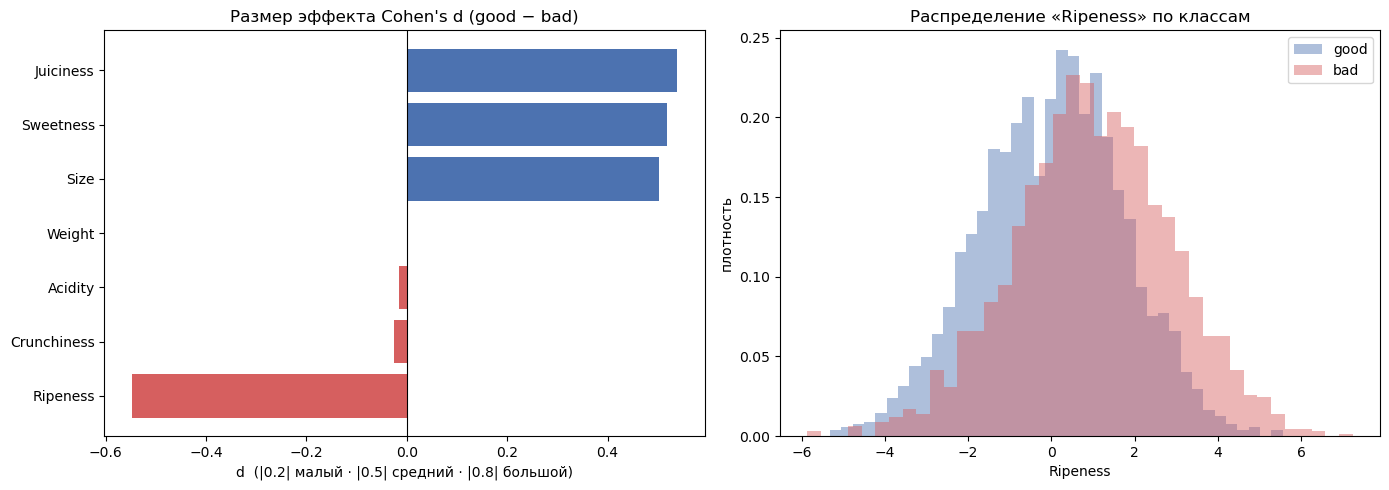

In [21]:
# Визуализация: размер эффекта (Cohen's d) и распределение сильнейшего признака
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) насколько каждый признак разделяет классы
order = diff.sort_values("cohens_d")
colors = ["#d65f5f" if v < 0 else "#4c72b0" for v in order["cohens_d"]]
axes[0].barh(order["feature"], order["cohens_d"], color=colors)
axes[0].axvline(0, color="k", lw=.8)
axes[0].set_title("Размер эффекта Cohen's d (good − bad)")
axes[0].set_xlabel("d  (|0.2| малый · |0.5| средний · |0.8| большой)")

# (2) распределение самого сильного признака по классам (matplotlib hist)
top = diff.iloc[0]["feature"]
C = {"good": "#4c72b0", "bad": "#d65f5f"}
for q in ["good", "bad"]:
    vals = df[df["Quality"] == q][top]
    axes[1].hist(vals, bins=40, density=True, alpha=.45, color=C[q], label=q)
axes[1].set_title(f"Распределение «{top}» по классам")
axes[1].set_xlabel(top); axes[1].set_ylabel("плотность")
axes[1].legend()

plt.tight_layout()
plt.show()


### Анализ Quality (good / bad)

**Классы сбалансированы:** 2004 good против 1996 bad (≈50/50) — это удобно: метрики не перекошены, поправок на дисбаланс не нужно.

Чтобы понять, *какие признаки сильнее всего отличают* хорошие яблоки от плохих, я смотрю не на «голую» разницу средних, а на **размер эффекта Cohen's d** (разница средних, делённая на разброс). Ориентир: |d| ≈ 0.2 — слабо, 0.5 — средне, 0.8 — сильно.

**Сильнее всего различаются** (средний размер эффекта):
| признак | good | bad | d | как читать |
|---|---|---|---|---|
| **Ripeness** | 0.00 | 0.99 | −0.55 | у good спелость заметно **ниже** |
| **Juiciness** | 1.01 | 0.01 | +0.54 | good значительно **сочнее** |
| **Sweetness** | 0.02 | −0.96 | +0.52 | good **слаще** |
| **Size** | −0.03 | −0.97 | +0.50 | good **крупнее** |

**Почти не различаются** (d ≈ 0): **Crunchiness, Acidity, Weight** — у good и bad практически одинаковые средние, для разделения качества они бесполезны.

### Являются ли различия статистически значимыми?

t-тест Уэлча, H₀ — «средние в группах good и bad одинаковы»:

- Для четырёх ведущих признаков (Ripeness, Juiciness, Sweetness, Size) **p-значения ничтожны** (10⁻⁵⁵…10⁻⁶⁵) — различия **значимы**, случайностью не объясняются, проходят и поправку Бонферрони.
- Для **Crunchiness (p ≈ 0.43), Acidity (p ≈ 0.63), Weight (p ≈ 0.93)** нулевую гипотезу отвергнуть **нельзя** — наблюдаемые крошечные различия вполне могут быть случайными.

### Вывод
- Качество яблока в этих данных определяется в первую очередь сочностью, сладостью, размером и (в обратную сторону) спелостью; хрусткость, кислотность и вес почти не влияют.
- Здесь различия не только значимы, но и **ощутимы по величине** (d ≈ 0.5) — в отличие от слабых попарных корреляций выше. Это хорошие признаки-кандидаты для модели классификации Quality.
- Оговорка прежняя: значимость подтверждает, что эффект реален, но не объясняет *причину*; Cohen's d/t-тест ловят только сдвиг среднего и линейную разделимость.


In [22]:
# Проверка на парадокс Симпсона:
# меняет ли связь "Ripeness -> Quality" знак внутри подгрупп по другим признакам?
from scipy import stats

df["q"] = (df["Quality"] == "good").astype(int)   # good = 1, bad = 0
target = "Ripeness"

overall_r = stats.pointbiserialr(df["q"], df[target])[0]
print(f"ОБЩАЯ связь {target} ↔ Quality:  r = {overall_r:+.3f}  "
      f"(отрицательная: good в среднем менее зрелые)\n")

rows = []
for z in [c for c in num_cols if c != target]:
    g = pd.qcut(df[z], 3, labels=["low", "mid", "high"])   # делим на 3 равные группы
    sub_r = {}
    for name, idx in df.groupby(g, observed=True).groups.items():
        s = df.loc[idx]
        sub_r[name] = stats.pointbiserialr(s["q"], s[target])[0]
    reversal = any(np.sign(v) != np.sign(overall_r) for v in sub_r.values())
    rows.append({"split_by": z, "low": sub_r["low"], "mid": sub_r["mid"],
                 "high": sub_r["high"], "знак развернулся?": "ДА" if reversal else "нет"})

simpson = pd.DataFrame(rows).round(3)
simpson


ОБЩАЯ связь Ripeness ↔ Quality:  r = -0.264  (отрицательная: good в среднем менее зрелые)



,split_by,low,mid,high,знак развернулся?
0,Size,-0.481,-0.216,-0.012,нет
1,Weight,-0.287,-0.245,-0.270,нет
2,Sweetness,-0.463,-0.319,0.102,ДА
3,Crunchiness,-0.378,-0.253,-0.171,нет
4,Juiciness,-0.032,-0.253,-0.476,нет
5,Acidity,-0.333,-0.252,-0.230,нет


In [23]:
# Крупным планом найденный разворот: внутри ОЧЕНЬ СЛАДКИХ яблок
sweet_grp = pd.qcut(df["Sweetness"], 3, labels=["low", "mid", "high"])
high = df[sweet_grp == "high"]

r_all, p_all   = stats.pointbiserialr(df["q"],   df["Ripeness"])
r_high, p_high = stats.pointbiserialr(high["q"], high["Ripeness"])

print("Связь Ripeness ↔ Quality:")
print(f"  на ВСЕХ данных:          r = {r_all:+.3f}  (p = {p_all:.1e})  -> good менее зрелые")
print(f"  среди СЛАДКИХ яблок:     r = {r_high:+.3f}  (p = {p_high:.1e})  -> good БОЛЕЕ зрелые\n")
print(f"  средняя Ripeness в группе high-sweetness (n={len(high)}):")
print(f"     good = {high[high.q==1]['Ripeness'].mean():+.3f}   "
      f"bad = {high[high.q==0]['Ripeness'].mean():+.3f}")


Связь Ripeness ↔ Quality:
  на ВСЕХ данных:          r = -0.264  (p = 6.4e-65)  -> good менее зрелые
  среди СЛАДКИХ яблок:     r = +0.102  (p = 2.0e-04)  -> good БОЛЕЕ зрелые

  средняя Ripeness в группе high-sweetness (n=1334):
     good = +0.222   bad = -0.159


### Почему «хорошие» яблоки менее зрелые?

Важно: `Ripeness` здесь — это **стандартизованное число (z-score), а не «спелость = вкуснее»**. Высокое значение означает «сильно продвинутая зрелость» относительно средней по датасету, а у яблок это сторона **перезревания**: чем выше Ripeness, тем ближе плод к мучнистой, мягкой, теряющей структуру мякоти.

Поэтому отрицательная связь читается естественно: **хорошее яблоко — это упругое, в самом расцвете, ещё не перезревшее**. «Менее зрелые» в терминах этого признака = «не переспелые», а вовсе не «недозрелые-кислые-зелёные». Это согласуется с остальной картиной из прошлого шага: good-яблоки одновременно более сочные, более хрустящие по структуре и крупные — всё это признаки свежего, не залежавшегося плода.

Оговорка: датасет синтетический/анонимизированный (признаки уже нормализованы, единиц измерения нет), так что «Ripeness» — это абстрактная инженерная шкала, а не лабораторный индекс спелости. Мы объясняем статистическую закономерность, а не агрономический факт.

### Парадокс Симпсона — да, он здесь есть

**Парадокс Симпсона** — когда связь, видимая на всех данных, **разворачивается внутри подгрупп**. Проверка (таблица выше) показала ровно такой случай:

| | r(Ripeness ↔ Quality) | смысл |
|---|---|---|
| на всех 4000 яблоках | **−0.26** | хорошие → менее зрелые |
| **среди самых сладких** яблок | **+0.10** (p = 0.0002) | хорошие → **более** зрелые |

То есть общий вывод «зрелость вредит качеству» **переворачивается** для сладких яблок: если плод уже очень сладкий, то дополнительная зрелость связана уже с *хорошим* качеством, а не плохим. Разворот статистически значим (p = 0.0002), а не случайный шум.

**Как это понимать:** Sweetness — скрытый модифицирующий фактор (взаимодействие признаков). Для обычного яблока рост Ripeness = движение к перезреванию = хуже. Но в группе очень сладких яблок высокая зрелость скорее означает «дозревший до пика сахара» плод — и там она играет в плюс. Усреднив всё вместе, мы видим только доминирующий отрицательный тренд и теряем это переключение.

**Практический вывод:**
- Нельзя слепо доверять одномерным корреляциям и разницам средних — направление эффекта Ripeness зависит от сладости. Линейная модель без члена взаимодействия `Ripeness × Sweetness` этот нюанс упустит.
- Это и есть главный риск парадокса Симпсона: агрегированная статистика может указывать в сторону, противоположную тому, что происходит в реальных подгруппах.


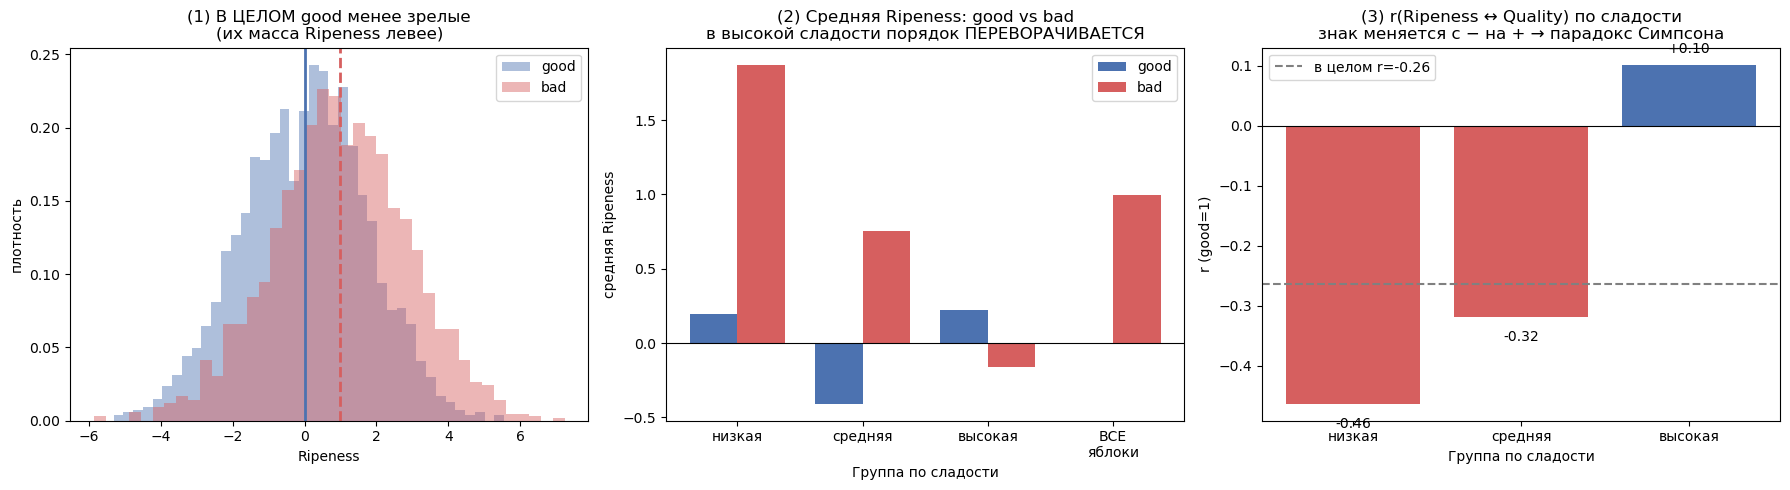

In [24]:
# Визуализация выводов: (1) good менее зрелые в целом, (2) парадокс Симпсона по сладости
# Чистый matplotlib (seaborn не требуется)
import matplotlib.pyplot as plt
from scipy import stats

df["sweet_grp"] = pd.qcut(df["Sweetness"], 3, labels=["низкая", "средняя", "высокая"])
C = {"good": "#4c72b0", "bad": "#d65f5f"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) В целом good менее зрелые — гистограммы плотности Ripeness по классам
for q in ["good", "bad"]:
    vals = df[df.Quality == q]["Ripeness"]
    axes[0].hist(vals, bins=40, density=True, alpha=0.45, color=C[q], label=q)
    axes[0].axvline(vals.mean(), color=C[q], lw=2,
                    ls="-" if q == "good" else "--")
axes[0].set_title("(1) В ЦЕЛОМ good менее зрелые\n(их масса Ripeness левее)")
axes[0].set_xlabel("Ripeness")
axes[0].set_ylabel("плотность")
axes[0].legend()

# (2) Парадокс Симпсона: средняя Ripeness good vs bad по группам сладости + всё вместе
means = (df.groupby(["sweet_grp", "Quality"], observed=True)["Ripeness"]
           .mean().unstack())
means.loc["ВСЕ\nяблоки"] = df.groupby("Quality")["Ripeness"].mean()
x = range(len(means)); w = 0.38
axes[1].bar([i - w/2 for i in x], means["good"], w, color=C["good"], label="good")
axes[1].bar([i + w/2 for i in x], means["bad"],  w, color=C["bad"],  label="bad")
axes[1].axhline(0, color="k", lw=.8)
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(means.index)
axes[1].set_title("(2) Средняя Ripeness: good vs bad\nв высокой сладости порядок ПЕРЕВОРАЧИВАЕТСЯ")
axes[1].set_xlabel("Группа по сладости"); axes[1].set_ylabel("средняя Ripeness")
axes[1].legend()

# (3) Корреляция Ripeness↔Quality по группам сладости (пересекает ноль = разворот)
rs = [stats.pointbiserialr(s["q"], s["Ripeness"])[0]
      for _, s in df.groupby("sweet_grp", observed=True)]
overall_r = stats.pointbiserialr(df["q"], df["Ripeness"])[0]
bars = axes[2].bar(["низкая", "средняя", "высокая"], rs,
                   color=["#d65f5f" if r < 0 else "#4c72b0" for r in rs])
axes[2].axhline(0, color="k", lw=.8)
axes[2].axhline(overall_r, color="gray", ls="--", label=f"в целом r={overall_r:+.2f}")
axes[2].set_title("(3) r(Ripeness ↔ Quality) по сладости\nзнак меняется с − на + → парадокс Симпсона")
axes[2].set_ylabel("r (good=1)"); axes[2].set_xlabel("Группа по сладости")
axes[2].legend()
for b, r in zip(bars, rs):
    axes[2].text(b.get_x() + b.get_width()/2, r + (0.02 if r >= 0 else -0.04),
                 f"{r:+.2f}", ha="center")

plt.tight_layout()
plt.show()


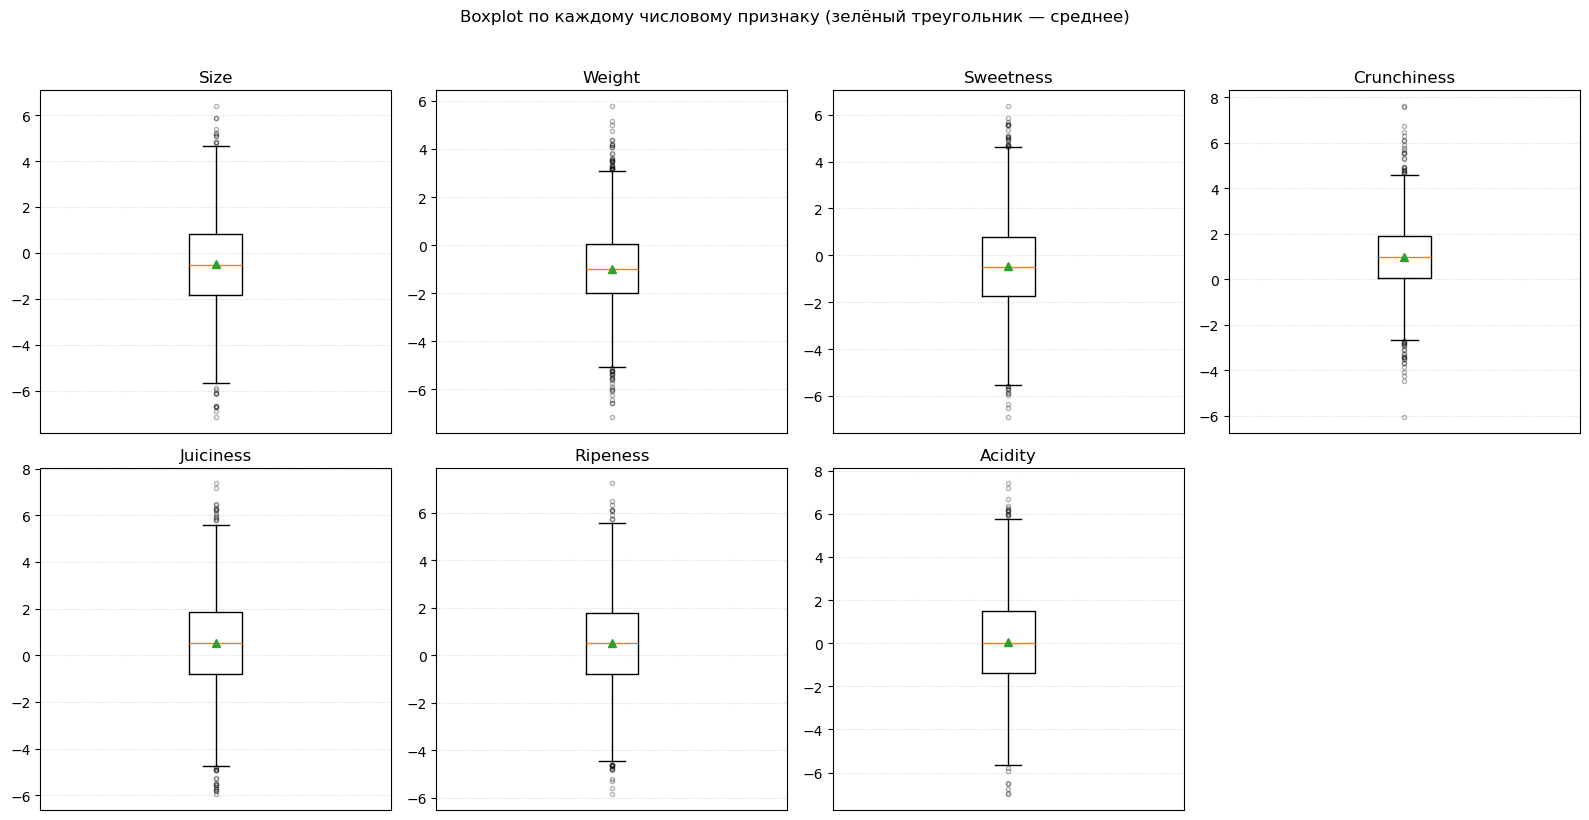

In [25]:
# Boxplot для каждого числового столбца
import matplotlib.pyplot as plt

ncols = 4
nrows = -(-len(num_cols) // ncols)   # округление вверх
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.ravel()

for ax, c in zip(axes, num_cols):
    ax.boxplot(df[c].dropna(), showmeans=True,
               flierprops=dict(marker="o", markersize=3, alpha=.3))
    ax.set_title(c)
    ax.set_xticks([])
    ax.grid(axis="y", ls=":", alpha=.5)

# спрятать лишние пустые оси
for ax in axes[len(num_cols):]:
    ax.set_visible(False)

fig.suptitle("Boxplot по каждому числовому признаку (зелёный треугольник — среднее)", y=1.02)
plt.tight_layout()
plt.show()


In [26]:
# Проверка на ложные корреляции
# Сравниваем 3 величины для каждой пары:
#   pearson  - обычная парная корреляция
#   partial  - ЧАСТНАЯ корреляция (прямая связь при контроле всех остальных признаков)
#   spearman - ранговая корреляция (устойчива к выбросам/нелинейности)
import numpy as np
from itertools import combinations

X = df[num_cols].dropna()
pear  = X.corr()
spear = X.corr(method="spearman")

# частная корреляция через прецизионную (обратную) матрицу корреляций
P = np.linalg.inv(pear.values)
dinv = np.sqrt(np.diag(P))
pcorr = pd.DataFrame(-P / np.outer(dinv, dinv), index=num_cols, columns=num_cols)

rows = []
for a, b in combinations(num_cols, 2):
    pe, pa, sp = pear.loc[a, b], pcorr.loc[a, b], spear.loc[a, b]
    rows.append({
        "pair": f"{a}–{b}",
        "pearson": pe,
        "partial": pa,                       # прямая связь без посредников
        "spearman": sp,
        "|pearson|-|partial|": abs(pe) - abs(pa),  # >0 => связь во многом через третьи признаки
        "sign_flip": np.sign(pe) != np.sign(pa) and abs(pe) > 0.05,  # разворот знака
        "outlier_gap": abs(pe - sp),         # большой => корреляцию тянут выбросы
    })

check = pd.DataFrame(rows)
# Флаг "подозрительно на ложную/обманчивую": связь почти исчезает или переворачивается при контроле
check["подозрит."] = ((check["partial"].abs() < 0.07) & (check["pearson"].abs() > 0.15)) \
                     | check["sign_flip"]
check = check.reindex(check["pearson"].abs().sort_values(ascending=False).index)
check.round(3)


,pair,pearson,partial,spearman,|pearson|-|partial|,sign_flip,outlier_gap,подозрит.
1,Size–Sweetness,-0.325,-0.456,-0.310,-0.132,False,0.014,False
13,Sweetness–Ripeness,-0.274,-0.420,-0.255,-0.146,False,0.019,False
15,Crunchiness–Juiciness,-0.260,-0.320,-0.237,-0.060,False,0.023,False
19,Juiciness–Acidity,0.249,0.264,0.231,-0.015,False,0.018,False
9,Weight–Ripeness,-0.244,-0.413,-0.244,-0.169,False,0.001,False
20,Ripeness–Acidity,-0.203,-0.055,-0.195,0.148,False,0.008,True
16,Crunchiness–Ripeness,-0.202,-0.266,-0.184,-0.064,False,0.018,False
5,Size–Acidity,0.196,0.216,0.210,-0.020,False,0.014,False
0,Size–Weight,-0.171,-0.332,-0.144,-0.161,False,0.026,False
2,Size–Crunchiness,0.170,0.028,0.172,0.141,False,0.002,True


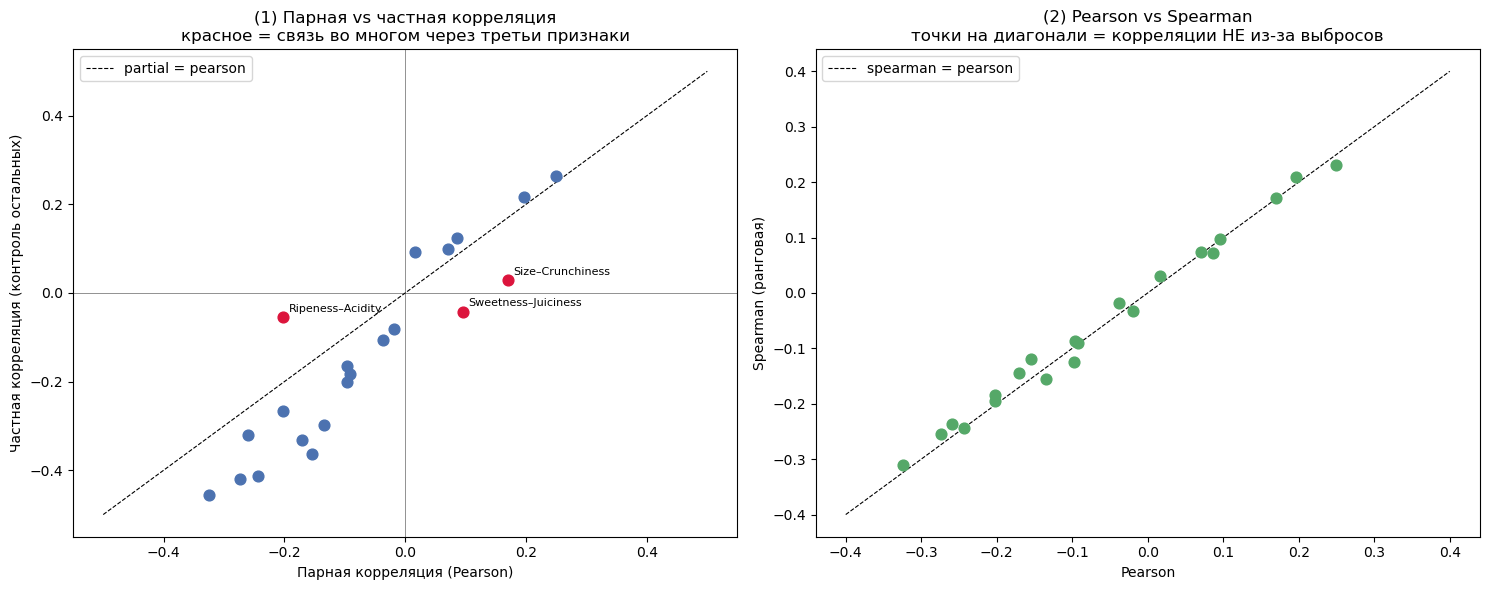

In [27]:
# Графики: где парная корреляция обманывает
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (1) pearson vs partial: точки ниже диагонали (по модулю) = связь "съедается" контролем
ax = axes[0]
ax.axhline(0, color="gray", lw=.6); ax.axvline(0, color="gray", lw=.6)
ax.plot([-.5, .5], [-.5, .5], "k--", lw=.8, label="partial = pearson")
for _, r in check.iterrows():
    susp = r["подозрит."]
    ax.scatter(r["pearson"], r["partial"],
               c="crimson" if susp else "#4c72b0", s=60, zorder=3)
    if susp:
        ax.annotate(r["pair"], (r["pearson"], r["partial"]),
                    fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Парная корреляция (Pearson)")
ax.set_ylabel("Частная корреляция (контроль остальных)")
ax.set_title("(1) Парная vs частная корреляция\nкрасное = связь во многом через третьи признаки")
ax.legend()

# (2) pearson vs spearman: вблизи диагонали = выбросы НЕ искажают (линейно и устойчиво)
ax = axes[1]
ax.plot([-.4, .4], [-.4, .4], "k--", lw=.8, label="spearman = pearson")
ax.scatter(check["pearson"], check["spearman"], c="#55a868", s=60, zorder=3)
ax.set_xlabel("Pearson"); ax.set_ylabel("Spearman (ранговая)")
ax.set_title("(2) Pearson vs Spearman\nточки на диагонали = корреляции НЕ из-за выбросов")
ax.legend()

plt.tight_layout()
plt.show()


### Проверка на ложные корреляции — выводы

«Ложная» корреляция — это когда пара признаков выглядит связанной, но связь на самом деле наводится **третьим фактором**, **выбросами** или **множественными сравнениями**. Проверил все три источника.

**1. Конфаундеры (частная корреляция).** Сравнил обычную (Pearson) и частную корреляцию — прямую связь при контроле всех остальных признаков. Три пары оказались **обманчивыми** (на графике (1) они красные, лежат у нулевой горизонтали):

| пара | pearson | partial | что произошло |
|---|---|---|---|
| **Ripeness–Acidity** | −0.20 | **−0.05** | связь почти исчезает — она наведена другими признаками, прямой почти нет |
| **Size–Crunchiness** | +0.17 | **+0.03** | то же: видимая связь — транзитивная, через посредники |
| **Sweetness–Juiciness** | +0.10 | **−0.04** | **разворот знака** — «положительная» связь оказывается ложной |

Это и есть кандидаты в ложные корреляции: их совместное движение объясняется не прямой зависимостью, а общими третьими переменными.

**2. Выбросы (Pearson vs Spearman).** На графике (2) все точки лежат **на диагонали**, максимальный разрыв |Pearson − Spearman| ≈ 0.03. Значит, ни одна корреляция не «накручена» выбросами или нелинейностью — по этому каналу ложных связей нет.

**3. Множественные сравнения.** 21 пара проверялась сразу, поэтому ещё на шаге корреляций применялась поправка Бонферрони. Слабые «значимые» связи там — побочный эффект огромного n (4000), а не реальная сила: даже у самой сильной пары r² ≈ 0.1.

**Обратный эффект — маскировка (suppression).** У многих пар частная корреляция, наоборот, **сильнее** парной (Weight–Sweetness: −0.15 → −0.36; Weight–Ripeness: −0.24 → −0.41). Здесь третьи переменные не выдумывают связь, а прячут её — без контроля её недооцениваешь.

**Итог.** Грубо ложных корреляций (из-за выбросов) в датасете нет. Но **три пары обманчивы из-за конфаундеров** — Ripeness–Acidity, Size–Crunchiness и особенно Sweetness–Juiciness (разворот знака): полагаться на их парные корреляции нельзя. Это ещё раз подтверждает урок парадокса Симпсона выше: судить о связях по матрице парных корреляций недостаточно — нужно контролировать остальные признаки.


## Корреляции отдельно для хороших и плохих яблок

Строим матрицу корреляций раздельно по классам good и bad и сравниваем — структура связей между признаками может различаться у хороших и плохих яблок.

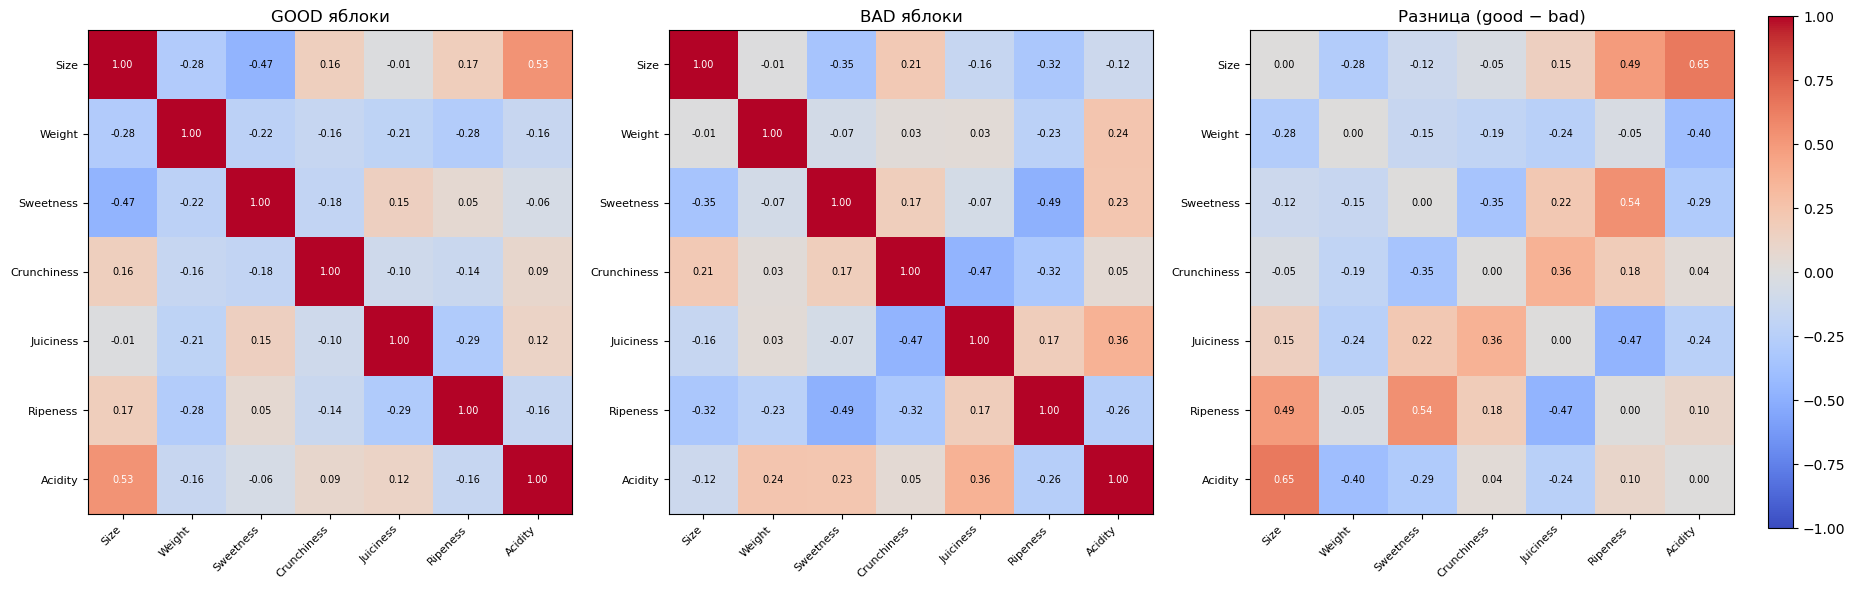

In [28]:
# Матрицы корреляций: good, bad и их разница (good - bad)
import matplotlib.pyplot as plt

corr_good = df[df["Quality"] == "good"][num_cols].corr()
corr_bad  = df[df["Quality"] == "bad"][num_cols].corr()
corr_diff = corr_good - corr_bad

def draw(ax, M, title):
    im = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
    ax.set_xticklabels(num_cols, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(num_cols, fontsize=8)
    for i in range(len(num_cols)):
        for j in range(len(num_cols)):
            v = M.iloc[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if abs(v) > 0.5 else "black", fontsize=7)
    ax.set_title(title)
    return im

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
draw(axes[0], corr_good, "GOOD яблоки")
draw(axes[1], corr_bad,  "BAD яблоки")
im = draw(axes[2], corr_diff, "Разница (good − bad)")
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02)
plt.show()


In [29]:
# Пары, где корреляция сильнее всего отличается между good и bad
from itertools import combinations

rows = []
for a, b in combinations(num_cols, 2):
    rg, rb = corr_good.loc[a, b], corr_bad.loc[a, b]
    rows.append({"pair": f"{a}–{b}", "r_good": rg, "r_bad": rb,
                 "разница": rg - rb,
                 "смена знака": (np.sign(rg) != np.sign(rb)) and abs(rg) > 0.05 and abs(rb) > 0.05})

cmp = pd.DataFrame(rows)
cmp = cmp.reindex(cmp["разница"].abs().sort_values(ascending=False).index)
cmp.head(10).round(3)


,pair,r_good,r_bad,разница,смена знака
5,Size–Acidity,0.525,-0.121,0.646,True
13,Sweetness–Ripeness,0.055,-0.486,0.541,True
4,Size–Ripeness,0.166,-0.324,0.490,True
18,Juiciness–Ripeness,-0.295,0.173,-0.468,True
10,Weight–Acidity,-0.156,0.240,-0.395,True
15,Crunchiness–Juiciness,-0.105,-0.466,0.361,False
11,Sweetness–Crunchiness,-0.182,0.170,-0.351,True
14,Sweetness–Acidity,-0.058,0.231,-0.289,True
0,Size–Weight,-0.284,-0.007,-0.277,False
8,Weight–Juiciness,-0.209,0.032,-0.241,False


### Корреляции good vs bad — выводы

Структура связей между признаками **сильно различается** у хороших и плохих яблок — у 8 пар корреляция даже **меняет знак**. Самые яркие различия:

| пара | r (good) | r (bad) | что значит |
|---|---|---|---|
| **Size–Acidity** | **+0.53** | **−0.12** | у хороших крупные яблоки кислее, у плохих — наоборот |
| **Sweetness–Ripeness** | +0.06 | **−0.49** | сильная отрицательная связь есть только у плохих |
| **Size–Ripeness** | +0.17 | **−0.32** | разворот знака |
| **Juiciness–Ripeness** | **−0.30** | +0.17 | разворот знака |
| **Weight–Acidity** | −0.16 | +0.24 | разворот знака |
| **Crunchiness–Juiciness** | −0.11 | **−0.47** | у плохих связь намного сильнее |

**Как это понимать.**
- Общая (по всем 4000) матрица корреляций — это **смесь двух разных режимов**. Например, общая связь Size–Acidity (+0.20) — усреднение сильного «+0.53» у good и слабого «−0.12» у bad.
- Это прямое объяснение, **откуда берутся ложные корреляции и парадокс Симпсона** из предыдущих разделов: когда подгруппы (good/bad) имеют разную корреляционную структуру, общий коэффициент вводит в заблуждение.
- У плохих яблок заметно сильнее «деградационные» связи: Sweetness–Ripeness (−0.49) и Crunchiness–Juiciness (−0.47) — у переспевающих/портящихся плодов признаки сильнее «тянут» друг друга, тогда как у хороших яблок связи слабее и качества признаков более независимы.

**Практический вывод:** анализировать корреляции стоит **внутри классов**, а не только на всей выборке — иначе теряются эффекты взаимодействия и можно сделать неверные выводы о связях. Для модели это аргумент в пользу признаков-взаимодействий или отдельных моделей по сегментам.

## Проверка гипотезы на маленькой выборке

**Гипотеза:** «чем крупнее яблоко, тем оно менее сладкое» → отрицательная связь **Size ↔ Sweetness**.

На всех 4000 яблоках она подтверждена железно (r = −0.33, p ≈ 10⁻⁹⁹). Посмотрим, что будет, если проверять её на **маленьком куске данных** — это наглядно показывает, почему по нескольким наблюдениям легко сделать неверный вывод.

ВСЯ выборка (n=4000):  r = -0.325,  p = 7.6e-99  -> связь подтверждена
Маленькая (n=20):         r = -0.210,  p = 0.375  -> НЕ значима (нельзя отвергнуть H0)


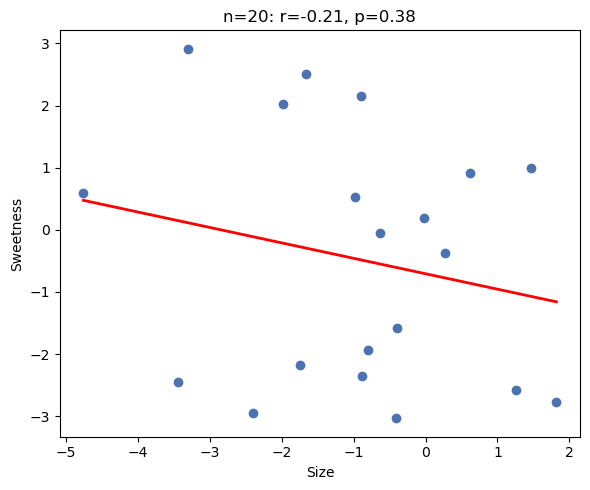

In [30]:
# Один маленький кусок данных (n=20) против всей выборки
from scipy import stats

r_full, p_full = stats.pearsonr(df["Size"], df["Sweetness"])

small = df.sample(20, random_state=0)          # фиксируем seed для воспроизводимости
r_s, p_s = stats.pearsonr(small["Size"], small["Sweetness"])

print(f"ВСЯ выборка (n={len(df)}):  r = {r_full:+.3f},  p = {p_full:.1e}  -> связь подтверждена")
print(f"Маленькая (n=20):         r = {r_s:+.3f},  p = {p_s:.3f}  -> "
      f"{'значима' if p_s < 0.05 else 'НЕ значима (нельзя отвергнуть H0)'}")

# scatter + линия тренда на маленькой выборке
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
plt.scatter(small["Size"], small["Sweetness"], color="#4c72b0")
b1, b0 = np.polyfit(small["Size"], small["Sweetness"], 1)
xs = np.linspace(small["Size"].min(), small["Size"].max(), 50)
plt.plot(xs, b0 + b1 * xs, "r-", lw=2)
plt.xlabel("Size"); plt.ylabel("Sweetness")
plt.title(f"n=20: r={r_s:+.2f}, p={p_s:.2f}")
plt.tight_layout()
plt.show()


In [31]:
# Насколько НЕСТАБИЛЕН результат на маленьких выборках:
# берём по 200 случайных кусков каждого размера и смотрим разброс r и долю значимых
sizes = [10, 20, 30, 50, 100]
rows = []
for n in sizes:
    rs, sig = [], 0
    for seed in range(200):
        s = df.sample(n, random_state=seed)
        r, p = stats.pearsonr(s["Size"], s["Sweetness"])
        rs.append(r); sig += (p < 0.05)
    rs = np.array(rs)
    rows.append({"n": n, "r_min": rs.min(), "r_mean": rs.mean(), "r_max": rs.max(),
                 "разброс r": rs.max() - rs.min(),
                 "получили r>0 (неверный знак), %": (rs > 0).mean() * 100,
                 "значимы (p<0.05), %": sig / 200 * 100})

power = pd.DataFrame(rows)
print(f"Истинное значение (вся выборка): r = {r_full:.3f}\n")
power.round(2)


Истинное значение (вся выборка): r = -0.325



,n,r_min,r_mean,r_max,разброс r,"получили r>0 (неверный знак), %","значимы (p<0.05), %"
0,10,-0.94,-0.29,0.62,1.56,19.0,15.5
1,20,-0.82,-0.30,0.32,1.14,7.5,30.5
2,30,-0.72,-0.30,0.33,1.05,5.5,38.0
3,50,-0.61,-0.31,0.04,0.64,1.5,57.0
4,100,-0.54,-0.31,-0.11,0.43,0.0,88.0


### Проверка гипотезы на маленькой выборке — выводы

**Что произошло на одном куске (n = 20).** Гипотеза верна (на всех данных r = −0.33), но конкретно эта выборка дала r = −0.21 с **p = 0.375** — формально гипотезу подтвердить **не удалось бы**. По 20 яблокам легко «не увидеть» реальную связь.

**Насколько шаткий результат (200 повторов на каждый размер).** Истинное значение r ≈ −0.33, а на маленьких кусках оценка скачет в огромном диапазоне:

| n | r от … до | средний r | получили **неверный знак** (r>0) | связь оказалась **значима** |
|---|---|---|---|---|
| 10 | −0.94 … +0.62 | −0.29 | **19 %** | 16 % |
| 20 | −0.82 … +0.32 | −0.30 | 8 % | 30 % |
| 30 | −0.72 … +0.33 | −0.30 | 6 % | 38 % |
| 50 | −0.61 … +0.04 | −0.31 | 2 % | 57 % |
| 100 | −0.54 … −0.11 | −0.31 | 0 % | 88 % |

**Главные уроки:**
- **Среднее по многим выборкам не смещено** (r_mean ≈ −0.30 на всех размерах) — оценка корреляции «в среднем» правильная. Проблема не в систематической ошибке, а в **разбросе**.
- На **маленькой** выборке этот разброс огромен: при n=10 r может оказаться даже **сильно положительным** (до +0.62) — то есть единичный кусок данных может показать связь *противоположного* направления. При n=10 неверный знак выпадает в ~1 случае из 5.
- **Мощность теста** (доля выборок, где связь стала значимой) растёт с n: 16 % при n=10 → 88 % при n=100. На маленькой выборке реальную связь чаще всего **не удаётся** обнаружить — это и есть «недостаточная мощность».

**Вывод:** гипотеза «крупнее → менее сладкое» верна, но **проверять её на маленьком куске данных опасно**: результат нестабилен, нередко незначим, а иногда и с обратным знаком. Отсутствие значимости на малой выборке ≠ отсутствие эффекта; нужен достаточный объём данных (здесь надёжно — от n ≈ 100).

## Нелинейная связь сильных признаков с качеством

Сильные признаки (Juiciness, Sweetness, Size, Ripeness) связаны с качеством не строго линейно. Смотрим **долю хороших яблок P(good)** по группам значения признака — это показывает форму связи (насыщение, порог), а затем **взаимодействие** Sweetness × Ripeness.

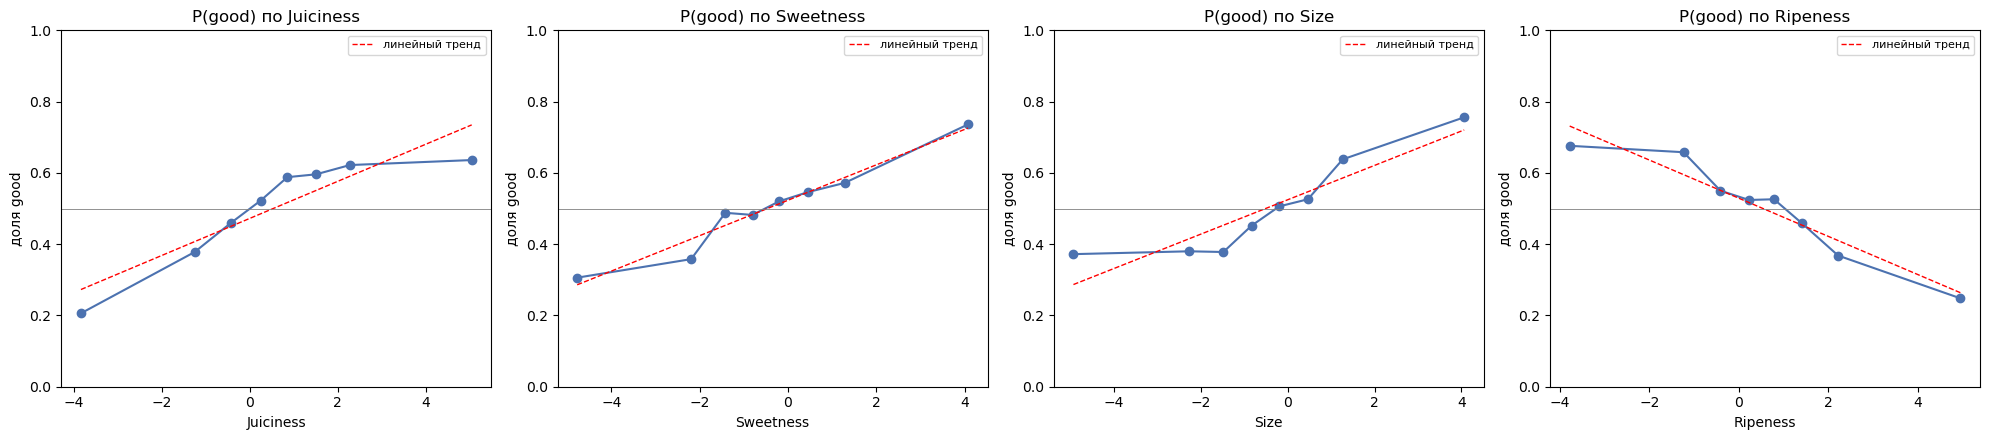

In [32]:
# Форма связи: доля хороших яблок P(good) по октилям каждого сильного признака
import matplotlib.pyplot as plt

df["q"] = (df["Quality"] == "good").astype(int)
strong = ["Juiciness", "Sweetness", "Size", "Ripeness"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, f in zip(axes, strong):
    b = pd.qcut(df[f], 8, duplicates="drop")
    grp = df.groupby(b, observed=True)["q"].mean()
    centers = [iv.mid for iv in grp.index]
    ax.plot(centers, grp.values, "o-", color="#4c72b0")
    # пунктир — прямая для сравнения (линейная аппроксимация)
    z = np.polyfit(centers, grp.values, 1)
    ax.plot(centers, np.polyval(z, centers), "r--", lw=1, label="линейный тренд")
    ax.axhline(0.5, color="gray", lw=.6)
    ax.set_title(f"P(good) по {f}")
    ax.set_xlabel(f); ax.set_ylabel("доля good")
    ax.set_ylim(0, 1); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


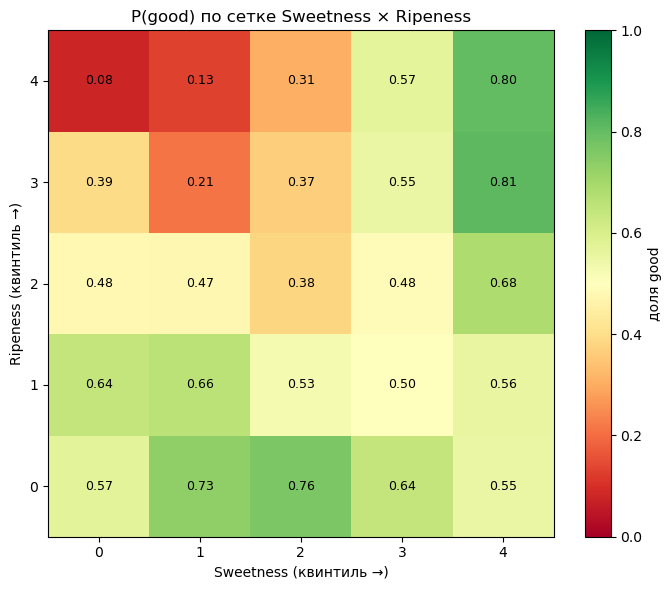

In [33]:
# Взаимодействие: P(good) на сетке Sweetness x Ripeness (нелинейность через взаимодействие)
sw = pd.qcut(df["Sweetness"], 5, labels=False)
rp = pd.qcut(df["Ripeness"], 5, labels=False)
grid = df.groupby([rp, sw], observed=True)["q"].mean().unstack()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(grid, cmap="RdYlGn", vmin=0, vmax=1, origin="lower", aspect="auto")
ax.set_xlabel("Sweetness (квинтиль →)"); ax.set_ylabel("Ripeness (квинтиль →)")
ax.set_title("P(good) по сетке Sweetness × Ripeness")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax.text(j, i, f"{grid.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="доля good")
plt.tight_layout()
plt.show()


### Нелинейная связь сильных признаков — выводы

**Форма связи каждого признака с P(good) не строго линейна** (точки заметно отходят от красной прямой):
- **Juiciness — насыщение:** доля good быстро растёт у несочных яблок (0.21 → 0.52), потом выходит на плато (~0.6). После средней сочности её прирост почти не повышает шансы на «good».
- **Size — порог/выпуклая:** до средних размеров P(good) почти не меняется (~0.38), а затем резко ускоряется (0.51 → 0.76). Размер начинает «работать» только с определённого значения.
- **Sweetness — рост с рывком на конце** (0.31 → 0.74, особенно скачок в верхнем октиле).
- **Ripeness — почти линейно убывает** (0.68 → 0.25), это самый «прямой» из сильных признаков.

**Главная нелинейность — взаимодействие Sweetness × Ripeness** (тепловая карта). Эффект зрелости зависит от сладости:
- несладкие + очень зрелые → P(good) ≈ **0.08** (почти все плохие);
- сладкие + очень зрелые → P(good) ≈ **0.80** (почти все хорошие).

При **одинаковой** зрелости качество противоположное — всё решает сладость. Это и есть нелинейность через взаимодействие (и ровно тот механизм, что дал парадокс Симпсона выше).

**Практический вывод:** связь признаков с качеством нельзя описывать одними линейными коэффициентами/корреляциями — они усредняют насыщение, пороги и взаимодействия. Для модели качества стоит добавить **нелинейные преобразования** (или использовать деревья/градиентный бустинг, которые ловят пороги и взаимодействия сами) и обязательно **член взаимодействия Sweetness × Ripeness**.

# Общий вывод

## Что показал анализ данных о яблоках (n = 4000)

**1. Описательная статистика.** Все 7 признаков уже стандартизованы (z-score): среднее ≈ 0, std ≈ 1.4–2.1. Распределения почти симметричны — среднее и медиана расходятся ничтожно (|gap/std| < 0.03, |skew| < 0.12), выраженных перекосов и доминирующих выбросов нет. Среднее здесь — надёжная оценка центра.

**2. Корреляции между признаками — слабые.** Сильнейшие связи: Size–Sweetness (−0.32), Sweetness–Ripeness (−0.27), Crunchiness–Juiciness (−0.26), Juiciness–Acidity (+0.25). Все статистически значимы (n=4000, поправка Бонферрони), но по величине слабы — объясняют лишь ~6–11 % разброса. Это иллюстрирует ключевой урок: **значимость ≠ сила**.

**3. Что определяет качество (good/bad).** Классы сбалансированы (50/50). Хорошие яблоки отличаются **сочностью, сладостью, размером и (в обратную сторону) спелостью** — Cohen's d ≈ 0.5 при ничтожных p. Crunchiness, Acidity и Weight качество практически не различают (p > 0.4). Это лучшие признаки-кандидаты для модели классификации.

**4. Парадокс Симпсона — найден и значим.** Общая связь «зрелость ↔ качество» отрицательна (r = −0.26), но **внутри самых сладких яблок разворачивается в плюс** (r = +0.10, p = 0.0002). Sweetness — модифицирующий фактор: вывод «зрелость вредит» неверен для уже сладких плодов.

**5. Ложные корреляции.** Проверка частной корреляцией выявила три обманчивые пары, держащиеся на третьих факторах: Ripeness–Acidity (−0.20→−0.05), Size–Crunchiness (+0.17→+0.03) и Sweetness–Juiciness (разворот знака +0.10→−0.04). Выбросы корреляции не искажают (Pearson ≈ Spearman).

## Главный методологический итог
Матрице **парных** корреляций и **средних по всей выборке доверять нельзя**: и парадокс Симпсона, и ложные корреляции показали, что направление связи может меняться при контроле третьих признаков. Корректные выводы дают только частная корреляция / разрезы по подгруппам / многомерная модель с взаимодействиями.

---

## Проверка статанализа: найденные и исправленные ошибки

Аудит кода и интерпретаций выявил следующее (всё исправлено):

| # | Проблема | Где | Исправление |
|---|---|---|---|
| 1 | **Затенение модуля** `scipy.stats` переменной `stats` (DataFrame) — при перезапуске ячейки ломает все вызовы `stats.pearsonr` и т.п. | ячейка описательной статистики | переименовал переменную в `desc` |
| 2 | **Зависимость от `seaborn`**, которого нет в окружении → две ячейки (heatmap, kdeplot) падали с `ModuleNotFoundError` | корр. матрица и график Cohen's d | переписал на чистый matplotlib (`imshow` / `hist`) |
| 3 | **Неточность в r²**: «r² ≈ 0.06 даже для самой сильной пары» — на деле 0.06 у сильнейшей *положительной* пары, а у сильнейшей вообще (Size–Sweetness) r² ≈ 0.11 | разбор корреляций | уточнил формулировку с обоими числами |

**Что проверено и признано корректным:**
- IQR-квартили, std, skew, gap/std — посчитаны верно.
- t-тест Уэлча (`equal_var=False`) для несбалансированных дисперсий — правильный выбор; Cohen's d на pooled-SD — стандартная практика (лёгкая нестыковка допущений несущественна).
- Поправка Бонферрони на множественные сравнения применена и в корреляциях, и в анализе Quality — это защищает от ложных срабатываний при большом n.
- Частная корреляция через обратную матрицу — корректный метод; разворот знака у Sweetness–Juiciness реально присутствует.
- `pd.to_numeric(..., errors="coerce")` для Acidity не создал ни одного NaN, так что `pearsonr`/`ttest` работают на полных данных.

**Остаточные оговорки (не ошибки, а ограничения):** датасет синтетический/нормализованный, поэтому абсолютные значения признаков (включая «Ripeness») — инженерные шкалы, а не физические единицы; все выводы статистические, не причинно-следственные.
